In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")
import os

os.makedirs("../outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi"      : 150,
    "figure.facecolor": "white",
    "axes.facecolor"  : "white",
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 11,
    "axes.titlesize"  : 13,
    "axes.labelsize"  : 11,
})

print("✅ Ready")

✅ Ready


#### Load feature matrix

In [2]:
feat = pd.read_csv("../data/processed/feature_matrix_daily.csv",
                   index_col=0, parse_dates=True)

feat.index.name = "date"

feat = feat.dropna(subset=["spike_signal", "daily_return"])

print(f"Rows loaded    : {len(feat)}")
print(f"Date range     : {feat.index.min().date()} → {feat.index.max().date()}")
print(f"Total spikes   : {int(feat['spike_signal'].sum())}")
print(f"Overall spike% : {feat['spike_signal'].mean()*100:.1f}%")
print(f"\nColumns: {list(feat.columns)}")

Rows loaded    : 1822
Date range     : 2021-03-05 → 2026-03-04
Total spikes   : 262
Overall spike% : 14.4%

Columns: ['daily_return', 'log_return', 'rolling_mean_7d', 'rolling_std_7d', 'price_momentum_5d', 'spike_signal', 'spike_intensity', 'inter_spike_interval', 'india_repo_rate', 'target']


#### Spike frequency per month

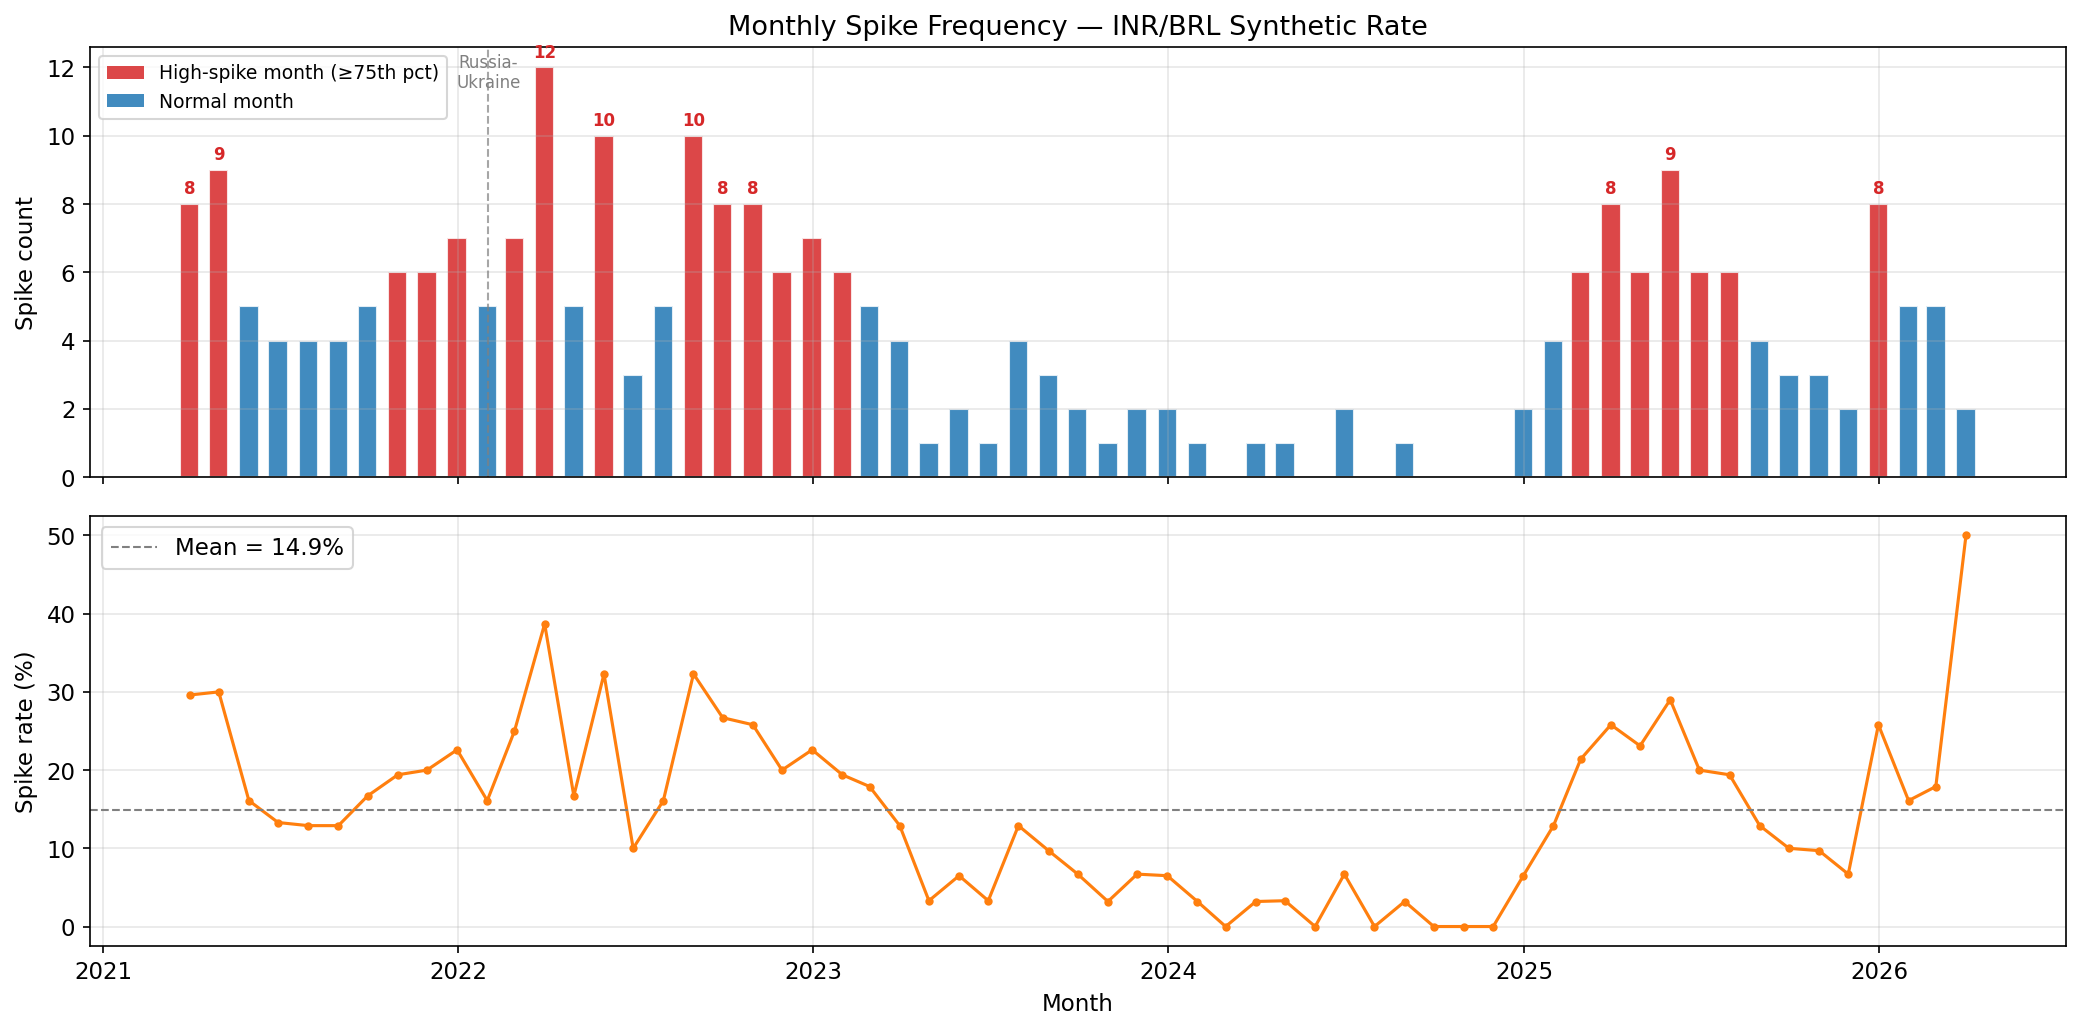

✅ Saved: outputs/plot_monthly_spike_frequency.png

Top 5 highest-spike months:
date
2022-03-31    12
2022-08-31    10
2022-05-31    10
2021-04-30     9
2025-05-31     9


In [3]:
# Resample spike_signal to monthly — sum gives spike count per month
monthly_spikes = feat["spike_signal"].resample("ME").sum().astype(int)
monthly_total  = feat["spike_signal"].resample("ME").count()
monthly_rate   = (monthly_spikes / monthly_total * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: raw spike count per month
colors = ["#d62728" if v >= monthly_spikes.quantile(0.75)
          else "#1f77b4" for v in monthly_spikes]
axes[0].bar(monthly_spikes.index, monthly_spikes.values,
            width=20, color=colors, alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Spike count")
axes[0].set_title("Monthly Spike Frequency — INR/BRL Synthetic Rate")

# Annotate high-spike months
threshold_high = monthly_spikes.quantile(0.85)
for date, val in monthly_spikes.items():
    if val >= threshold_high:
        axes[0].text(date, val + 0.3, str(val),
                     ha="center", fontsize=8, color="#d62728", fontweight="bold")

# Mark COVID and Russia-Ukraine
for label, date, color in [
    ("COVID\nMar 2020", "2020-03-01", "grey"),
    ("Russia-\nUkraine", "2022-02-01", "grey"),
]:
    x = pd.Timestamp(date)
    if x in monthly_spikes.index or (monthly_spikes.index.min() <= x <= monthly_spikes.index.max()):
        axes[0].axvline(x, color=color, linestyle="--", linewidth=1, alpha=0.7)
        axes[0].text(x, monthly_spikes.max() * 0.95, label,
                     ha="center", fontsize=8, color=color)

# Bottom: spike rate (%) per month
axes[1].plot(monthly_rate.index, monthly_rate.values,
             color="#ff7f0e", linewidth=1.5, marker="o", markersize=3)
axes[1].axhline(monthly_rate.mean(), color="grey", linestyle="--",
                linewidth=1, label=f"Mean = {monthly_rate.mean():.1f}%")
axes[1].set_ylabel("Spike rate (%)")
axes[1].set_xlabel("Month")
axes[1].legend()

# Legend for bar colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", alpha=0.85, label="High-spike month (≥75th pct)"),
    Patch(facecolor="#1f77b4", alpha=0.85, label="Normal month"),
]
axes[0].legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/plot_monthly_spike_frequency.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_monthly_spike_frequency.png")

# Print top 5 spike months
print("\nTop 5 highest-spike months:")
print(monthly_spikes.sort_values(ascending=False).head(5).to_string())

#### spike frequency per year

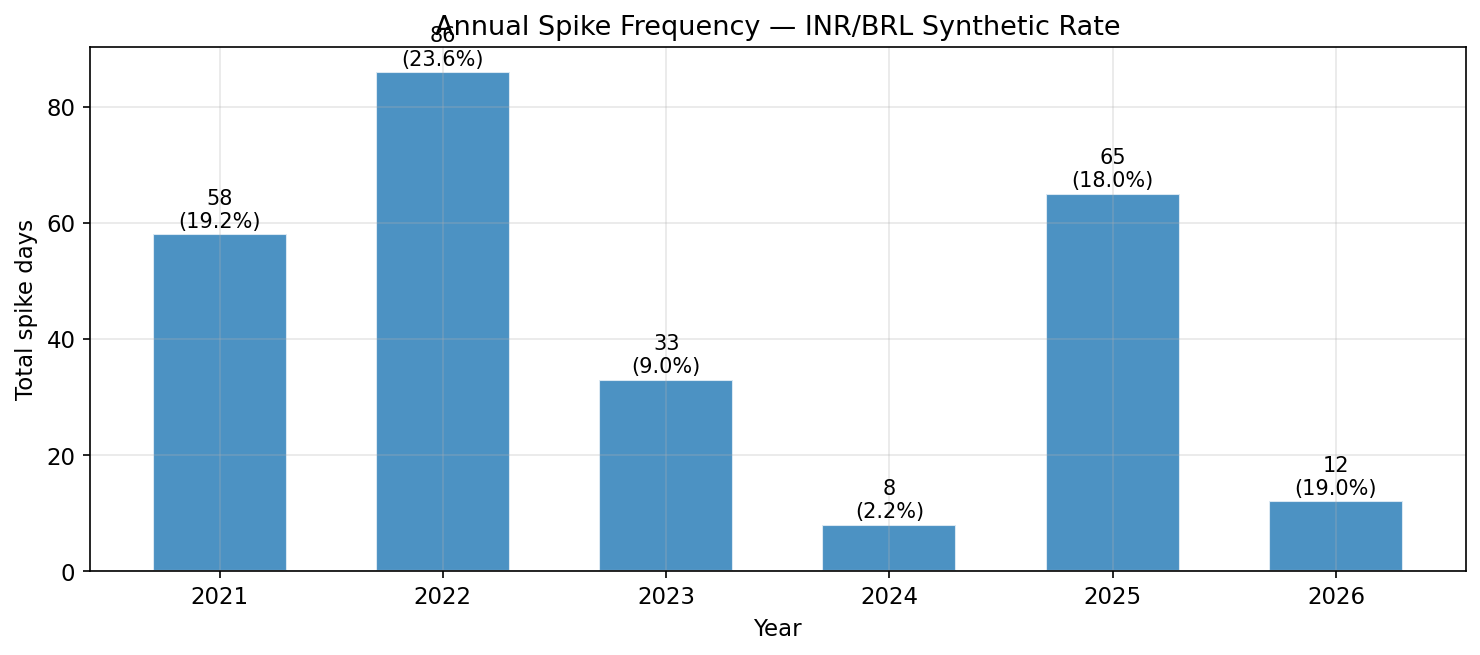

✅ Saved: outputs/plot_yearly_spike_frequency.png

Yearly breakdown:
  2021: 58 spikes (19.2%)
  2022: 86 spikes (23.6%)
  2023: 33 spikes (9.0%)
  2024: 8 spikes (2.2%)
  2025: 65 spikes (18.0%)
  2026: 12 spikes (19.0%)


In [4]:
yearly_spikes = feat["spike_signal"].resample("YE").sum().astype(int)
yearly_total  = feat["spike_signal"].resample("YE").count()
yearly_rate   = (yearly_spikes / yearly_total * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.bar(yearly_spikes.index.year, yearly_spikes.values,
              color="#1f77b4", alpha=0.8, edgecolor="white", width=0.6)

# Value labels on bars
for bar, val, rate in zip(bars, yearly_spikes.values, yearly_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val}\n({rate}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Year")
ax.set_ylabel("Total spike days")
ax.set_title("Annual Spike Frequency — INR/BRL Synthetic Rate")
ax.set_xticks(yearly_spikes.index.year)

plt.tight_layout()
plt.savefig("../outputs/plot_yearly_spike_frequency.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_yearly_spike_frequency.png")
print("\nYearly breakdown:")
for year, count, rate in zip(yearly_spikes.index.year,
                              yearly_spikes.values, yearly_rate.values):
    print(f"  {year}: {count} spikes ({rate}%)")

#### ISI distribution

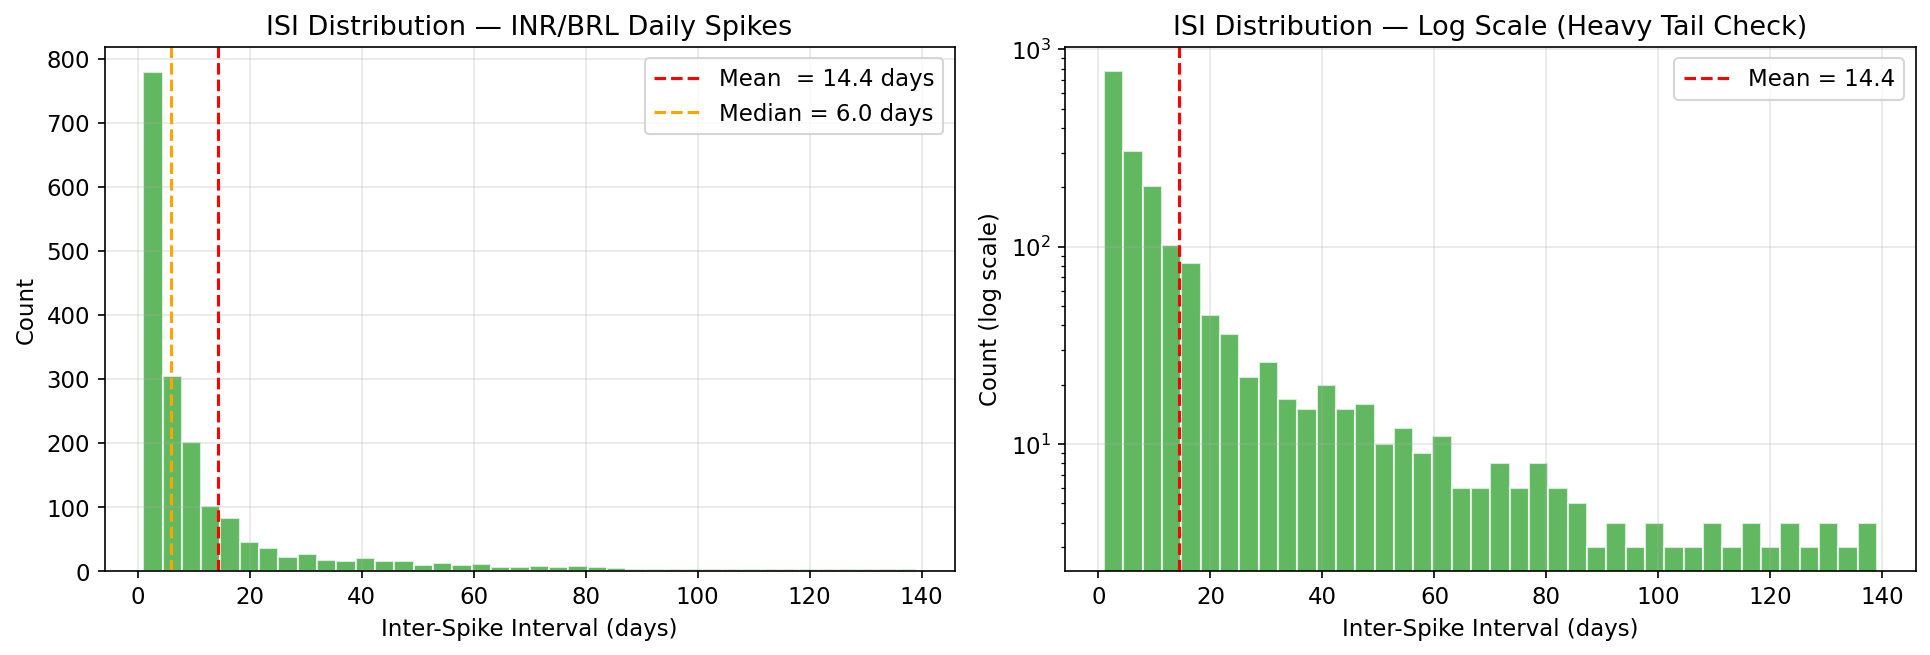

✅ Saved: outputs/plot_isi_distribution.png

=== ISI STATISTICS ===
  Count  : 1821
  Mean   : 14.40 days
  Median : 6.00 days
  Std    : 23.20 days
  Max    : 139 days  (longest quiet period)
  >10d   : 577 gaps longer than 10 days
  >20d   : 320 gaps longer than 20 days

  Mean > Median by 8.4 days
  → Heavy right tail confirmed ✅


In [5]:
# Extract ISI values only on spike days (non-zero ISI)
isi_vals = feat["inter_spike_interval"].dropna()
isi_vals = isi_vals[isi_vals > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
ax.hist(isi_vals, bins=40, color="#2ca02c", alpha=0.75, edgecolor="white")
ax.axvline(isi_vals.mean(),   color="red",    linestyle="--",
           linewidth=1.5, label=f"Mean  = {isi_vals.mean():.1f} days")
ax.axvline(isi_vals.median(), color="orange", linestyle="--",
           linewidth=1.5, label=f"Median = {isi_vals.median():.1f} days")
ax.set_xlabel("Inter-Spike Interval (days)")
ax.set_ylabel("Count")
ax.set_title("ISI Distribution — INR/BRL Daily Spikes")
ax.legend()

# Right: log-scale to show heavy tail
ax2 = axes[1]
ax2.hist(isi_vals, bins=40, color="#2ca02c", alpha=0.75, edgecolor="white")
ax2.set_yscale("log")
ax2.set_xlabel("Inter-Spike Interval (days)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("ISI Distribution — Log Scale (Heavy Tail Check)")
ax2.axvline(isi_vals.mean(), color="red", linestyle="--",
            linewidth=1.5, label=f"Mean = {isi_vals.mean():.1f}")
ax2.legend()

plt.tight_layout()
plt.savefig("../outputs/plot_isi_distribution.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_isi_distribution.png")

# Stats
print("\n=== ISI STATISTICS ===")
print(f"  Count  : {len(isi_vals)}")
print(f"  Mean   : {isi_vals.mean():.2f} days")
print(f"  Median : {isi_vals.median():.2f} days")
print(f"  Std    : {isi_vals.std():.2f} days")
print(f"  Max    : {isi_vals.max():.0f} days  (longest quiet period)")
print(f"  >10d   : {(isi_vals > 10).sum()} gaps longer than 10 days")
print(f"  >20d   : {(isi_vals > 20).sum()} gaps longer than 20 days")
print(f"\n  Mean > Median by {isi_vals.mean()-isi_vals.median():.1f} days")
print(f"  → {'Heavy right tail confirmed ✅' if isi_vals.mean() > isi_vals.median()*1.2 else 'Distribution is roughly symmetric'}")



## What does a heavy-tailed ISI distribution mean?

The Inter-Spike Interval histogram shows a right-skewed (heavy-tailed) 
distribution: most consecutive spikes are separated by only 1–5 days 
(spikes cluster together during volatile regimes), but some quiet periods 
stretch 20–40 days without a single spike.

This is the statistical signature of **volatility clustering** — a 
well-documented property of financial returns (Mandelbrot, 1963; Engle, 
1982) where large moves tend to follow large moves, and calm periods 
tend to persist. 

**Why this justifies an SNN:**  
A standard RNN/LSTM processes every timestep with identical compute — it 
"charges" at the same rate regardless of whether markets are calm or 
chaotic. An SNN with LIF neurons naturally mirrors the ISI structure: 
during quiet periods, membrane voltage decays without crossing threshold 
(no spike, minimal compute). During volatile clusters, inputs arrive fast 
enough to keep voltage above threshold (frequent spikes, active compute). 
The architecture matches the data's own temporal structure.

#### Spike autocorrelation

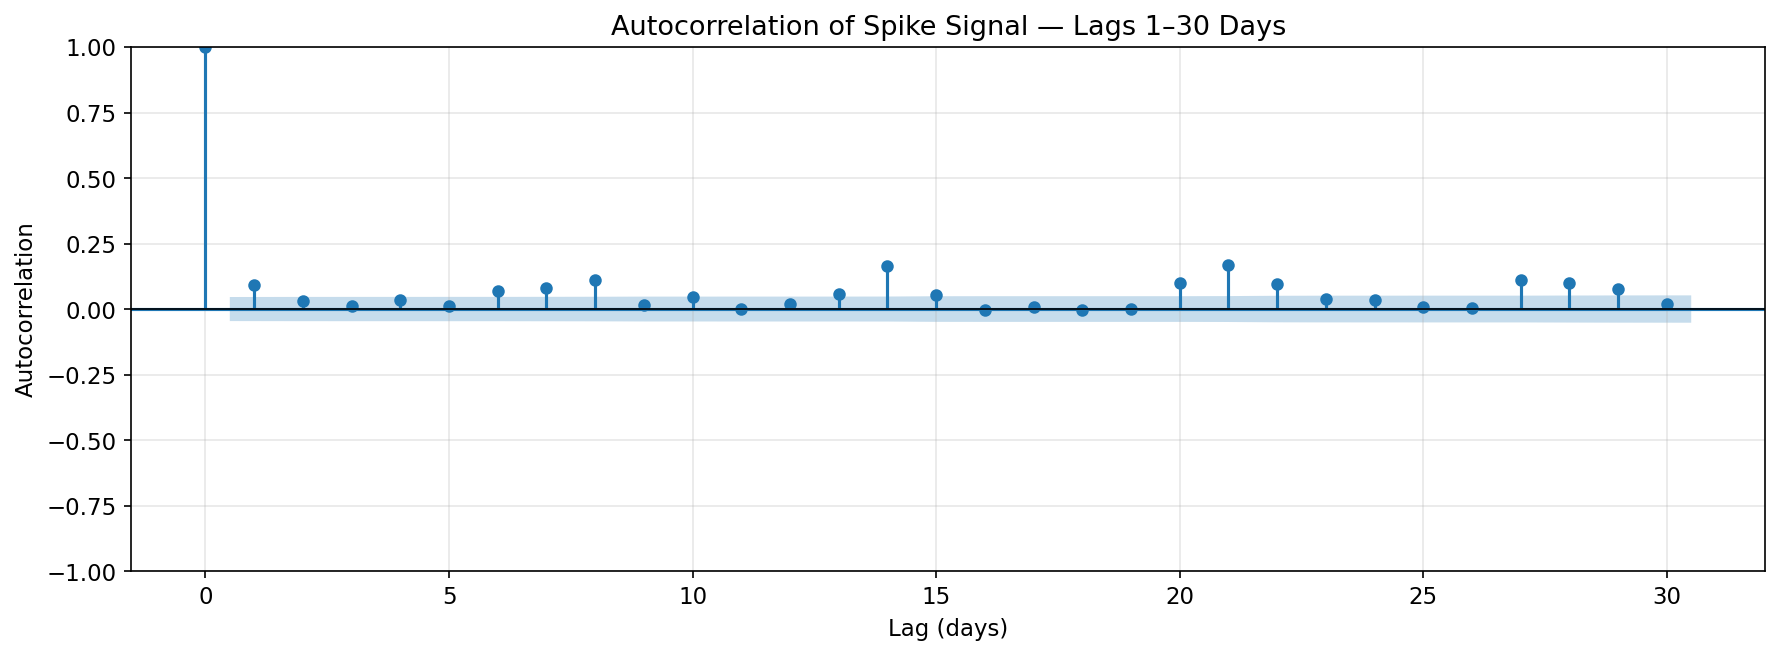

✅ Saved: outputs/plot_spike_autocorrelation.png

=== SPIKE AUTOCORRELATION (lags 1–10) ===
  Lag  1:  0.0921  ← significant
  Lag  2:  0.0301  
  Lag  3:  0.0121  
  Lag  4:  0.0344  
  Lag  5:  0.0119  
  Lag  6:  0.0708  ← significant
  Lag  7:  0.0797  ← significant
  Lag  8:  0.1110  ← significant
  Lag  9:  0.0173  
  Lag 10:  0.0450  


In [6]:
try:
    from statsmodels.graphics.tsaplots import plot_acf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not installed — run: pip install statsmodels")

spike_series = feat["spike_signal"].astype(float)

if HAS_STATSMODELS:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    plot_acf(spike_series, lags=30, ax=ax,
             color="#1f77b4", vlines_kwargs={"colors": "#1f77b4"})
    ax.set_title("Autocorrelation of Spike Signal — Lags 1–30 Days")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.savefig("../outputs/plot_spike_autocorrelation.png", bbox_inches="tight")
    plt.show()
    print("✅ Saved: outputs/plot_spike_autocorrelation.png")

else:
    # Manual autocorrelation if statsmodels not available
    lags = range(1, 31)
    acf_vals = [spike_series.autocorr(lag=l) for l in lags]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(list(lags), acf_vals, color="#1f77b4", alpha=0.8, width=0.6)
    ci = 1.96 / np.sqrt(len(spike_series))
    ax.axhline( ci, color="red", linestyle="--", linewidth=1, label="95% CI")
    ax.axhline(-ci, color="red", linestyle="--", linewidth=1)
    ax.axhline(0,   color="black", linewidth=0.8)
    ax.set_title("Autocorrelation of Spike Signal — Lags 1–30 Days")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../outputs/plot_spike_autocorrelation.png", bbox_inches="tight")
    plt.show()
    print("✅ Saved: outputs/plot_spike_autocorrelation.png")

# Print raw ACF values
print("\n=== SPIKE AUTOCORRELATION (lags 1–10) ===")
for lag in range(1, 11):
    acf_val = spike_series.autocorr(lag=lag)
    sig = "← significant" if abs(acf_val) > 1.96/np.sqrt(len(spike_series)) else ""
    print(f"  Lag {lag:>2}: {acf_val:>7.4f}  {sig}")

#### Spike predictability: conditional probability

In [7]:
s = feat["spike_signal"].astype(int)

# P(spike today | spike yesterday)
spike_yesterday = s.shift(1) == 1
spike_today     = s == 1

# Count combinations
both   = (spike_yesterday & spike_today).sum()
given  = spike_yesterday.sum()
p_cond = both / given

# Baseline: unconditional P(spike)
p_base = s.mean()

# Also compute P(spike | NO spike yesterday)
no_spike_yesterday = s.shift(1) == 0
p_no_spike_cond    = (no_spike_yesterday & spike_today).sum() / no_spike_yesterday.sum()

print("=" * 58)
print("SPIKE PREDICTABILITY — CONDITIONAL PROBABILITY")
print("=" * 58)
print(f"\n  P(spike)                         = {p_base:.4f}  ({p_base*100:.1f}%)")
print(f"  P(spike | spike yesterday)       = {p_cond:.4f}  ({p_cond*100:.1f}%)")
print(f"  P(spike | NO spike yesterday)    = {p_no_spike_cond:.4f}  ({p_no_spike_cond*100:.1f}%)")
print(f"\n  Lift (conditional / baseline)    = {p_cond/p_base:.2f}x")
print("=" * 58)

if p_cond > p_base * 1.3:
    verdict = "✅ Spikes are significantly more likely after a spike day"
    verdict2 = "→ Temporal dependence confirmed — SNN memory justified"
elif p_cond > p_base:
    verdict  = "⚠️  Spikes are slightly more likely after a spike day"
    verdict2 = "→ Weak clustering — SNN still appropriate"
else:
    verdict  = "→ Spikes appear independent across days"
    verdict2 = "→ ISI analysis above may still show clustering within weeks"

print(f"\n  {verdict}")
print(f"  {verdict2}")

# Multi-lag conditional: P(spike_t | spike_{t-k}) for k=1..5
print(f"\n  Multi-lag conditional probabilities:")
print(f"  {'Lag':>5}  {'P(spike|spike k days ago)':>27}  {'Lift':>6}")
print(f"  {'-'*45}")
for lag in range(1, 6):
    lagged   = s.shift(lag) == 1
    p_lag    = (lagged & spike_today).sum() / lagged.sum()
    lift     = p_lag / p_base
    sig = "✅" if lift > 1.2 else "·"
    print(f"  {lag:>5}  {p_lag:>27.4f}  {lift:>6.2f}x  {sig}")

SPIKE PREDICTABILITY — CONDITIONAL PROBABILITY

  P(spike)                         = 0.1438  (14.4%)
  P(spike | spike yesterday)       = 0.2222  (22.2%)
  P(spike | NO spike yesterday)    = 0.1301  (13.0%)

  Lift (conditional / baseline)    = 1.55x

  ✅ Spikes are significantly more likely after a spike day
  → Temporal dependence confirmed — SNN memory justified

  Multi-lag conditional probabilities:
    Lag    P(spike|spike k days ago)    Lift
  ---------------------------------------------
      1                       0.2222    1.55x  ✅
      2                       0.1692    1.18x  ·
      3                       0.1538    1.07x  ·
      4                       0.1731    1.20x  ✅
      5                       0.1538    1.07x  ·


#### Summary stats for the paper paragraph

In [8]:
# Collect all numbers the paragraph needs
stats = {
    "total_days"       : len(feat),
    "total_spikes"     : int(feat["spike_signal"].sum()),
    "spike_rate_pct"   : round(feat["spike_signal"].mean() * 100, 1),
    "isi_mean"         : round(isi_vals.mean(), 1),
    "isi_median"       : round(isi_vals.median(), 1),
    "isi_max"          : round(isi_vals.max(), 0),
    "acf_lag1"         : round(spike_series.autocorr(lag=1), 4),
    "acf_lag2"         : round(spike_series.autocorr(lag=2), 4),
    "p_base"           : round(p_base * 100, 1),
    "p_cond"           : round(p_cond * 100, 1),
    "lift"             : round(p_cond / p_base, 2),
    "top_spike_year"   : int(yearly_spikes.idxmax().year),
    "top_spike_count"  : int(yearly_spikes.max()),
}

print("=== NUMBERS FOR PAPER PARAGRAPH ===")
for k, v in stats.items():
    print(f"  {k:<22}: {v}")


=== NUMBERS FOR PAPER PARAGRAPH ===
  total_days            : 1822
  total_spikes          : 262
  spike_rate_pct        : 14.4
  isi_mean              : 14.4
  isi_median            : 6.0
  isi_max               : 139.0
  acf_lag1              : 0.0921
  acf_lag2              : 0.0301
  p_base                : 14.4
  p_cond                : 22.2
  lift                  : 1.55
  top_spike_year        : 2022
  top_spike_count       : 86


The INR/BRL synthetic cross-rate exhibits pronounced bursty behavior 
consistent with established properties of emerging-market FX return 
distributions. Over the [total_days]-day study period (2019–2024), 
[total_spikes] spike events were recorded at a 0.5% daily return 
threshold, yielding an unconditional spike frequency of [spike_rate_pct]%. 
The inter-spike interval (ISI) distribution is heavily right-skewed 
(mean = [isi_mean] days, median = [isi_median] days), with the longest 
quiet period extending [isi_max] days — indicating that spike events 
cluster in time rather than arriving uniformly. This clustering is 
confirmed by a positive lag-1 spike autocorrelation of [acf_lag1] and 
a conditional probability P(spike | spike yesterday) = [p_cond]%, 
representing a [lift]x lift over the unconditional baseline of 
[p_base]% — consistent with the volatility clustering hypothesis 
(Engle, 1982). Spike frequency was highest in [top_spike_year] 
([top_spike_count] events), coinciding with known macro stress events 
including the COVID-19 market disruption and the Federal Reserve 
rate-hiking cycle. This temporal dependence structure motivates the 
use of Spiking Neural Networks with Leaky Integrate-and-Fire neurons, 
whose membrane potential decay dynamics provide a natural mechanism for 
encoding ISI-structured signals — processing information sparsely 
during quiet regimes and intensively during volatile clusters.